In [102]:
import yaml
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict
import logging
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Meiryo'

logger = logging.getLogger(__name__)

In [103]:

df = pd.read_csv("data/shopping_behavior_updated.csv")

In [104]:
def load_encoding_config(path: Path) -> dict:
    """エンコーディング設定ファイルを読み込む

    Args:
        path (Path): YAMLファイルへのパス

    Returns:
        dict: エンコーディングマッピング
    """
    with path.open("r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    return config["encoding"]

config_path = Path("config/config.yaml")
encoding_config = load_encoding_config(config_path)


In [105]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

| 番号 | カラム名                    | 説明                          |
|------|-----------------------------|-------------------------------|
| 1    | Age                         | 年齢                          |
| 2    | Gender                      | 性別                          |
| 3    | Item Purchased              | 購入したアイテム              |
| 4    | Category                    | カテゴリ                      |
| 5    | Purchase Amount (USD)       | 購入金額（USD）               |
| 6    | Location                    | 位置（地域）                  |
| 7    | Size                        | サイズ                        |
| 8    | Color                       | 色                             |
| 9    | Season                      | 季節                          |
| 10   | Review Rating               | レビュー評価                  |
| 11   | Subscription Status         | サブスクリプションステータス  |
| 12   | Shipping Type               | 配送タイプ                    |
| 13   | Discount Applied            | 割引適用                      |
| 14   | Promo Code Used             | プロモコード使用             |
| 15   | Previous Purchases          | 過去の購入回数                |
| 16   | Payment Method              | 支払い方法                    |
| 17   | Frequency of Purchases      | 購入頻度                      |


In [107]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [108]:
df.isna().sum()


Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

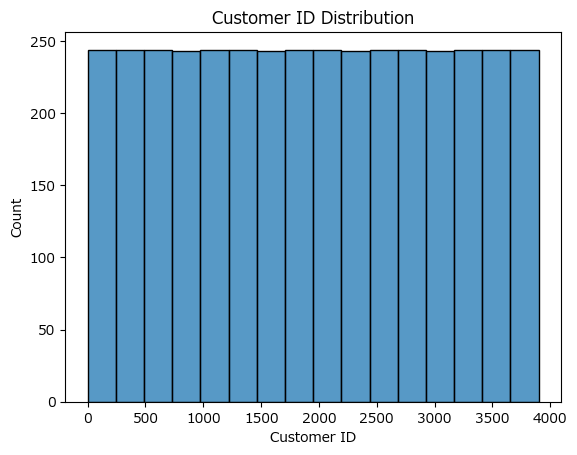

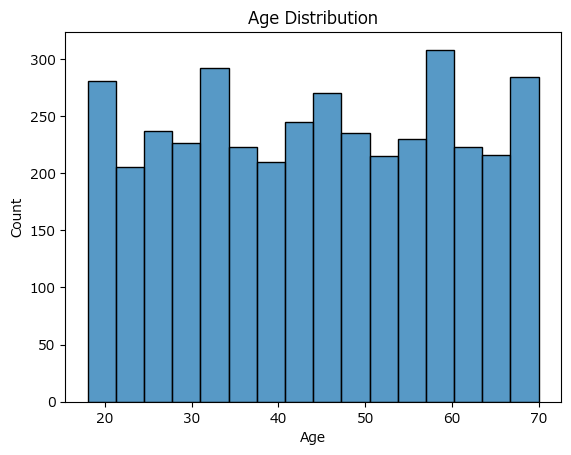

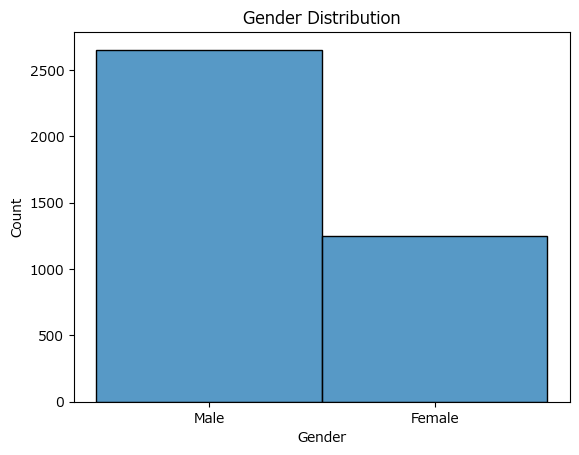

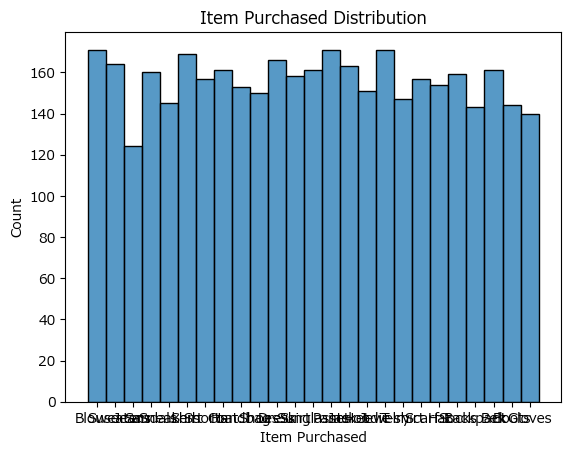

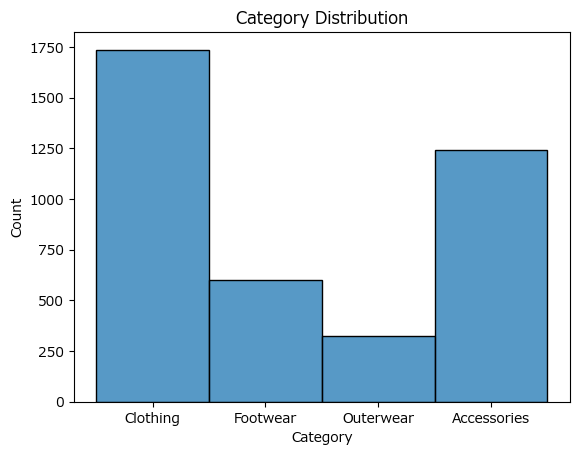

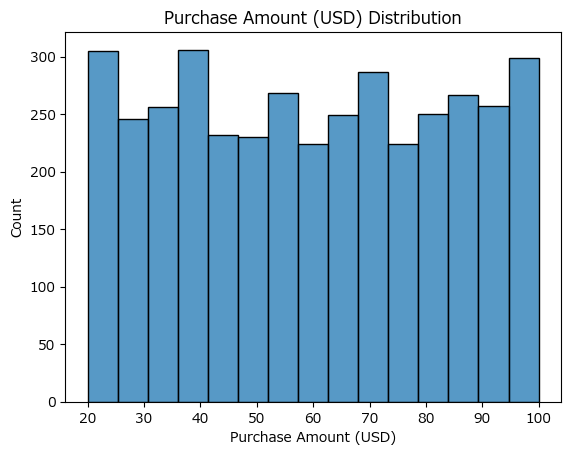

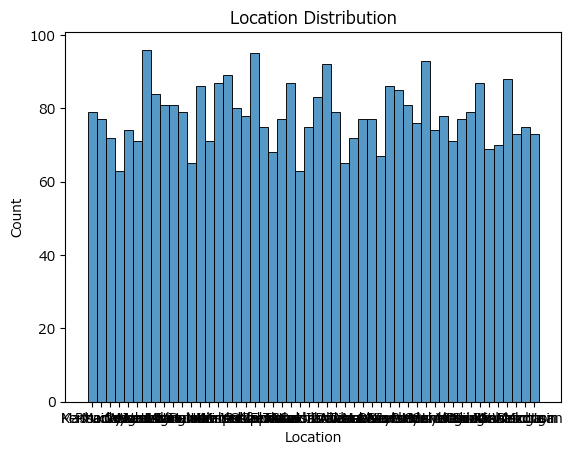

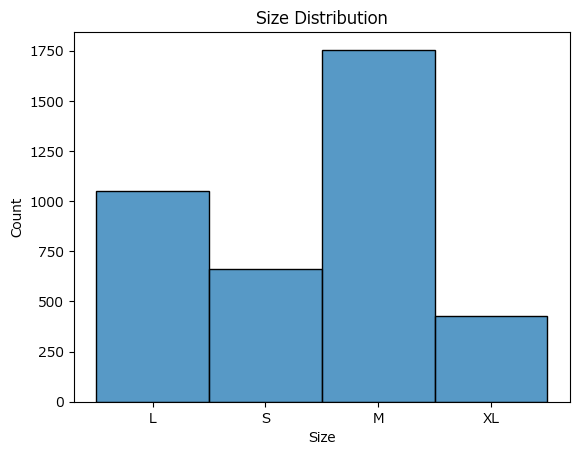

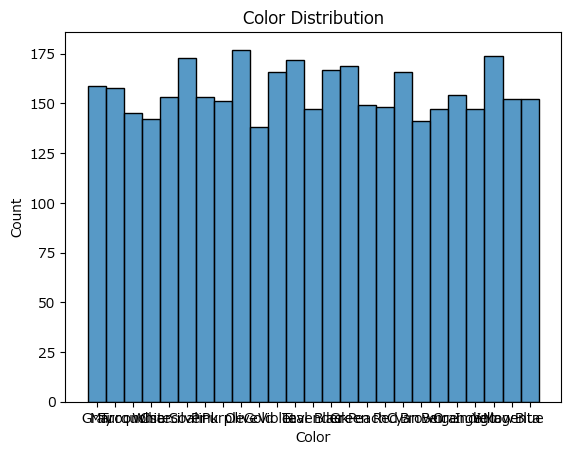

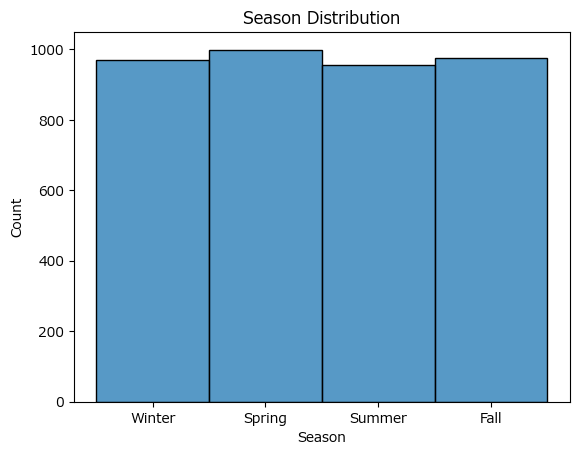

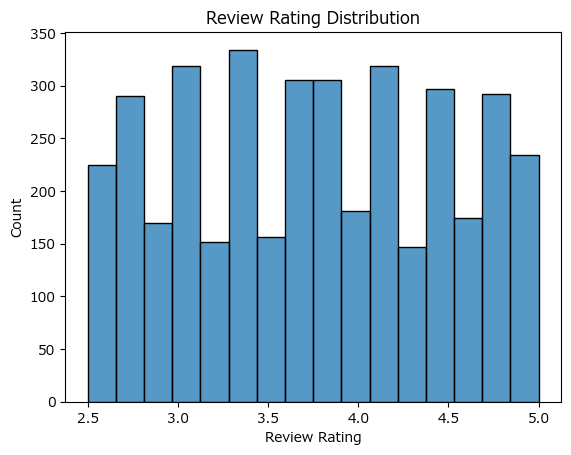

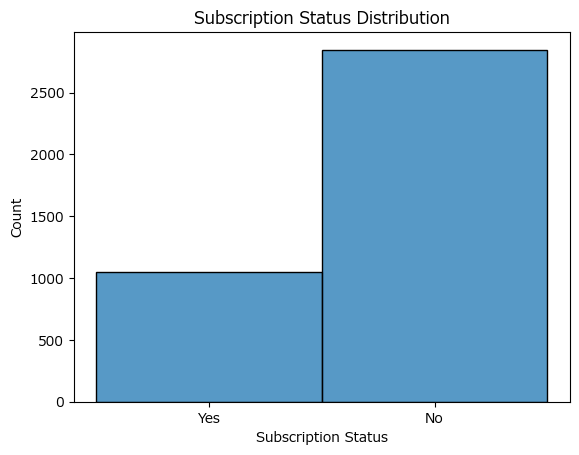

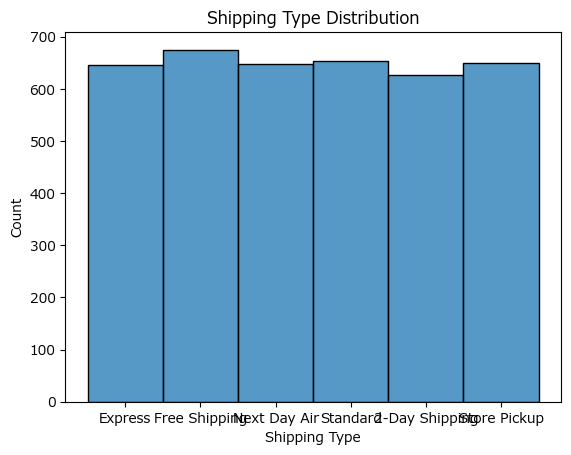

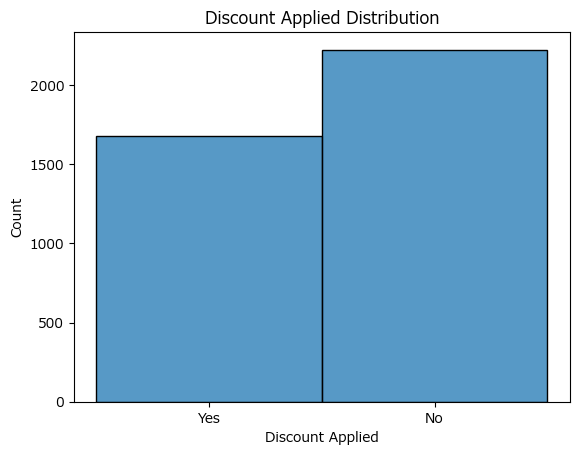

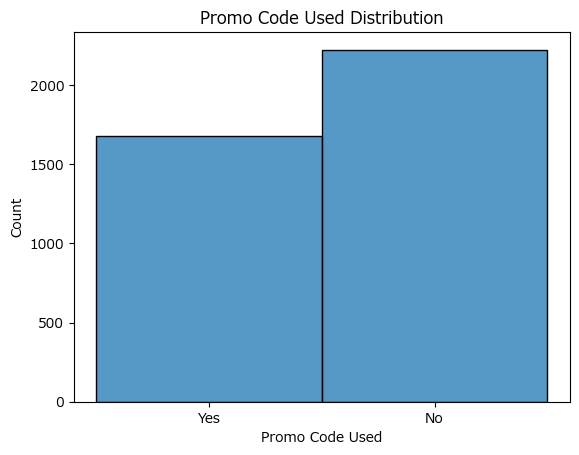

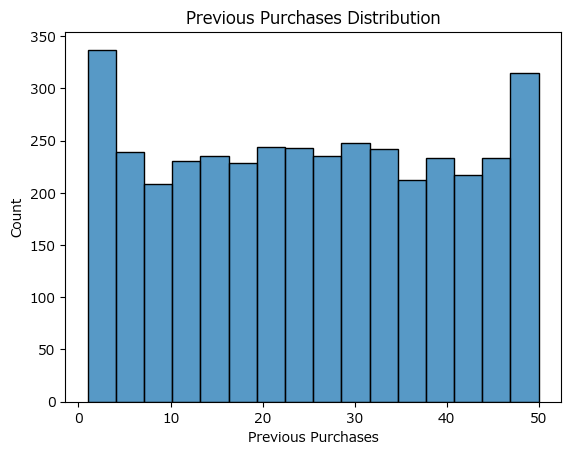

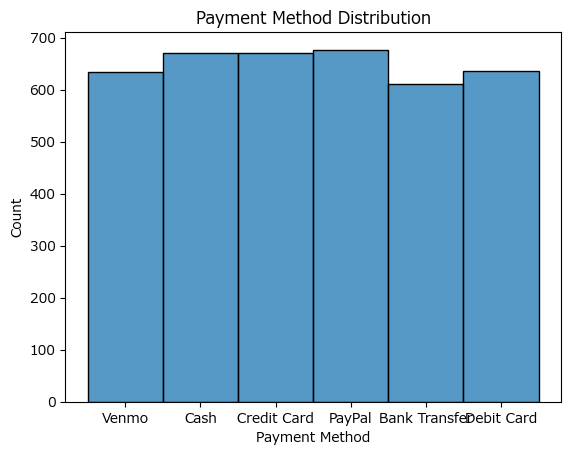

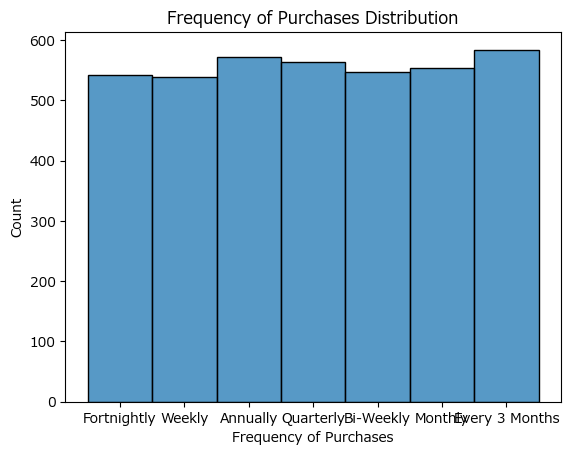

In [109]:
for column in df.columns:
    sns.histplot(df[column])
    plt.title(f'{column} Distribution')
    plt.show()

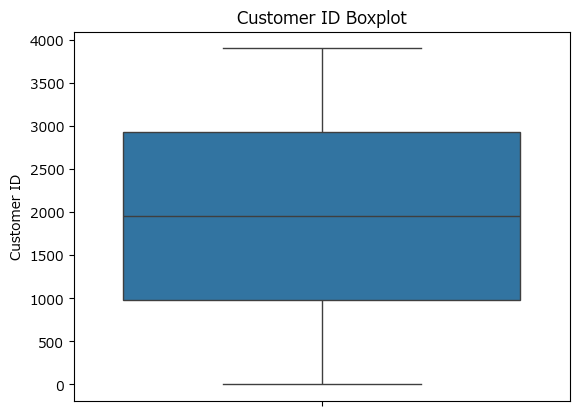

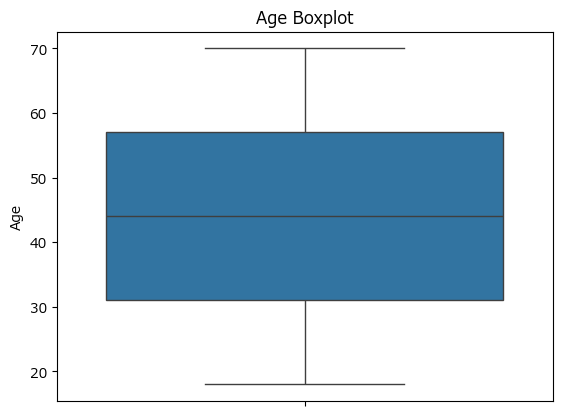

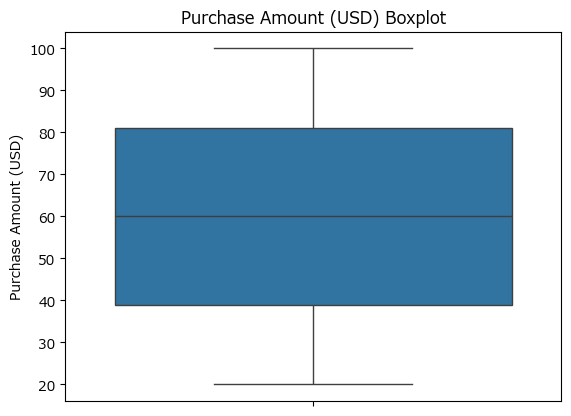

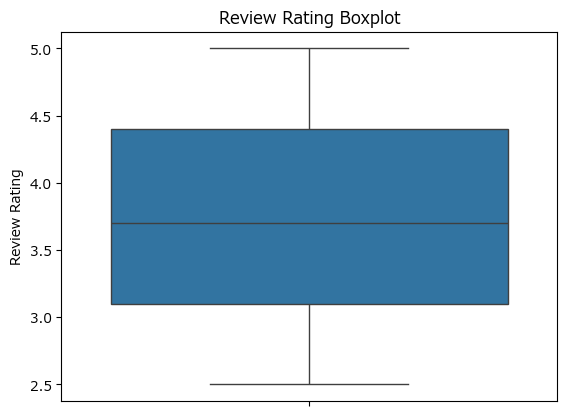

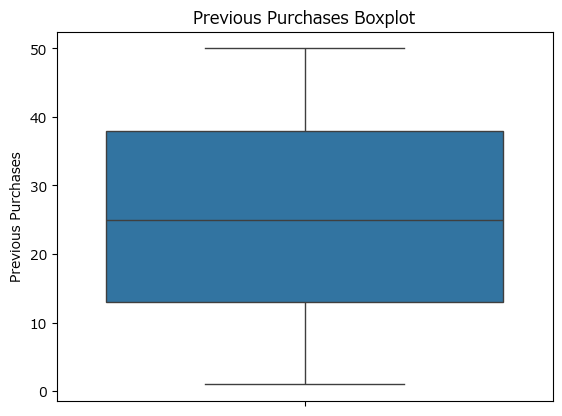

In [110]:
for column in df.select_dtypes(include=['int64', 'float64']).columns:
    sns.boxplot(y=df[column])
    plt.title(f'{column} Boxplot')
    plt.show()


In [111]:
for column in df.columns:
    if df[column].dtype == 'object':  # カテゴリカルなデータに対して
        print(f'--- {column} ---')
        value_counts = df[column].value_counts()
        percentage = df[column].value_counts(normalize=True) * 100
        
        # 結果表示
        print("ユニーク値とそのカウント:")
        print(value_counts)
        print("\n割合:")
        print(percentage)
        print("\n")


--- Gender ---
ユニーク値とそのカウント:
Gender
Male      2652
Female    1248
Name: count, dtype: int64

割合:
Gender
Male      68.0
Female    32.0
Name: proportion, dtype: float64


--- Item Purchased ---
ユニーク値とそのカウント:
Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Sandals       160
Socks         159
Skirt         158
Scarf         157
Shorts        157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64

割合:
Item Purchased
Blouse        4.384615
Pants         4.384615
Jewelry       4.384615
Shirt         4.333333
Dress         4.256410
Sweater       4.205128
Jacket        4.179487
Coat          4.128205
Sunglasses    4.128205
Belt          4.128205
Sandals       4.102564
Socks         4.076923
Skirt  

In [112]:
df.Category.unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

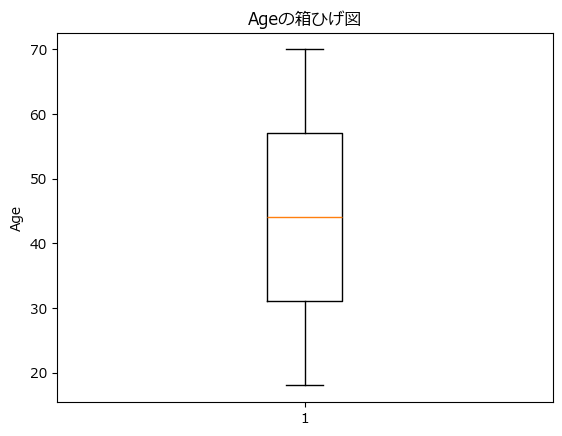

In [113]:
import matplotlib.pyplot as plt

plt.boxplot(df["Age"])
plt.title("Ageの箱ひげ図")
plt.ylabel("Age")
plt.show()


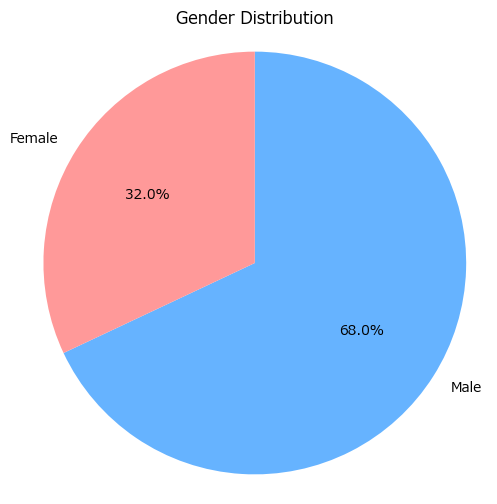

In [114]:
# 10色のカラーパレットを定義
COLOR_PALETTE = [
    "#66b3ff",  # ブルー
    "#ff9999",  # ピンク
    "#99ff99",  # グリーン
    "#ffcc99",  # オレンジ
    "#c2c2f0",  # ラベンダー
    "#ffb3e6",  # ライトピンク
    "#c2f0c2",  # ライトグリーン
    "#ff6666",  # レッド
    "#99ffff",  # アクア
    "#ffccff"   # ライトパープル
]


def create_pie(df, column, title, colors=None):
    data_count = df[column].value_counts()
    data_len = len(data_count.index)
    if colors is None:
        colors = COLOR_PALETTE[:data_len]

    # 円グラフの作成
    plt.figure(figsize=(6, 6))  # グラフのサイズを指定
    plt.pie(data_count, 
            labels=data_count.index,    # カウントされた性別をラベルとして使用
            colors=colors,
            autopct='%1.1f%%',             # パーセント表示
            startangle=90,                # 90度から開始
            counterclock=False)           # 時計回りに描画

    # 円グラフを円形に
    plt.axis('equal')

    # タイトルを追加
    plt.title(title)

    # グラフを表示
    plt.show()

colors = ['#66b3ff', '#ff9999']
title = 'Gender Distribution'
column = "Gender"
create_pie(df, column, title)

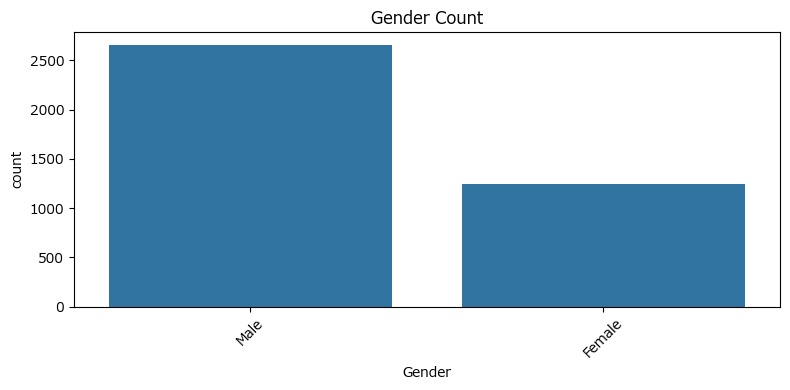

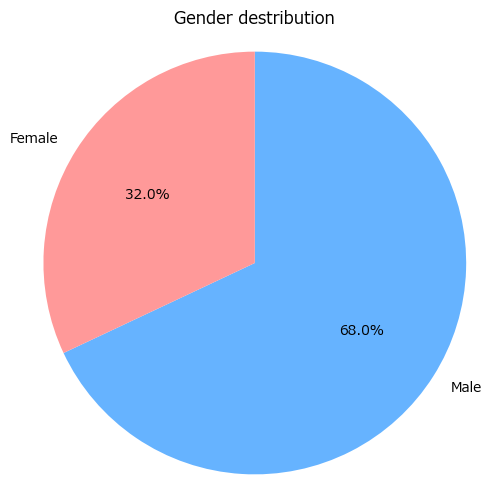

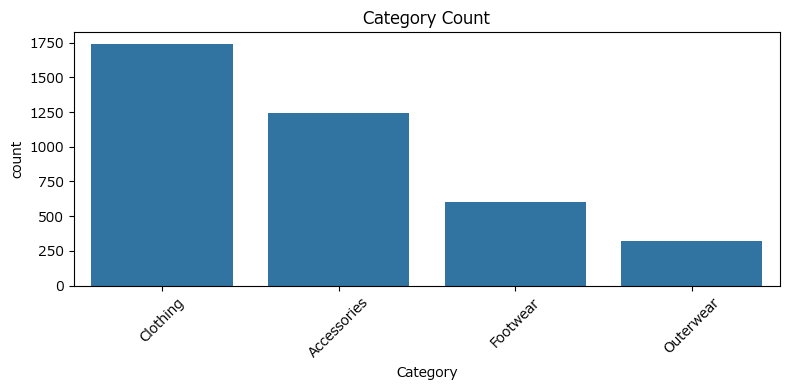

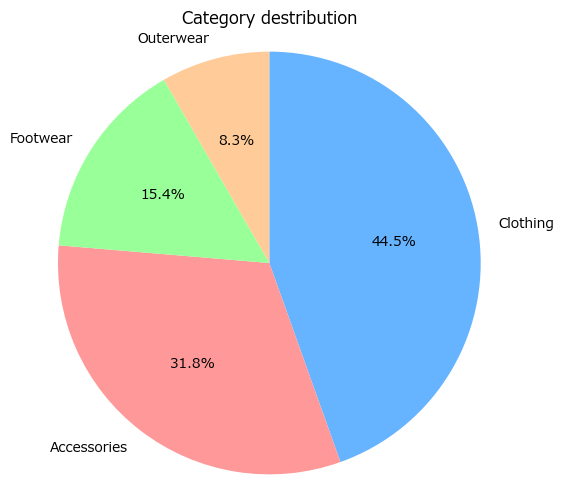

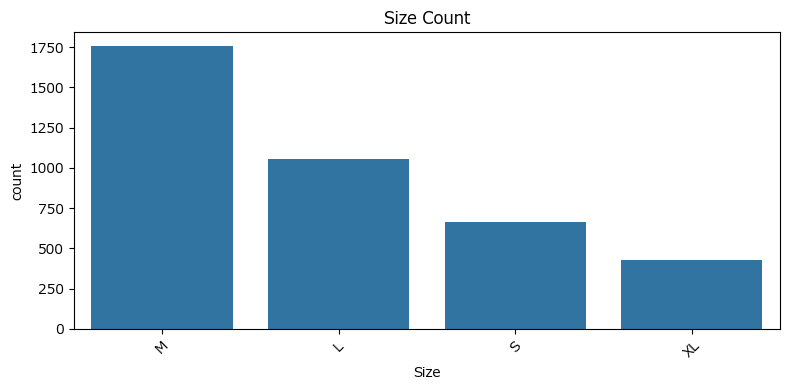

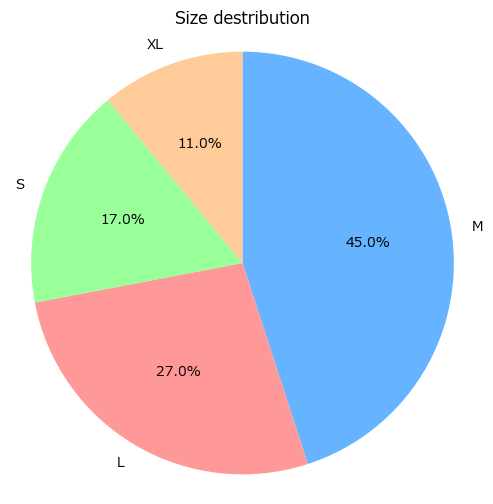

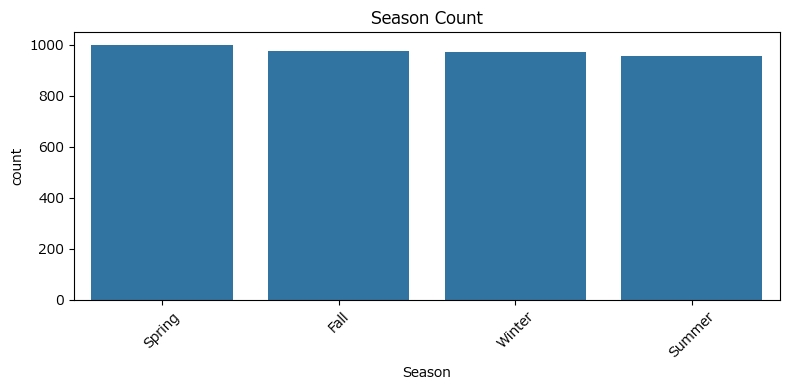

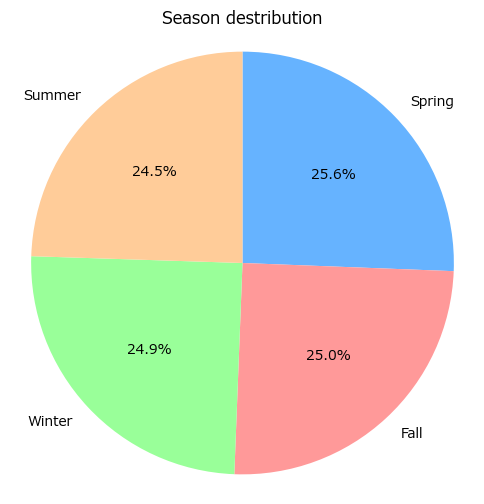

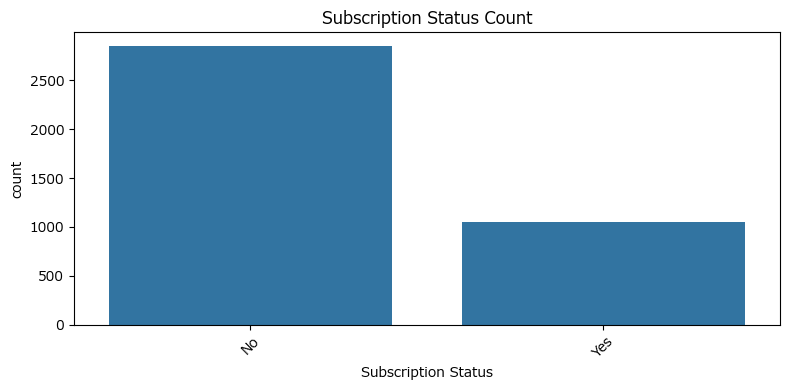

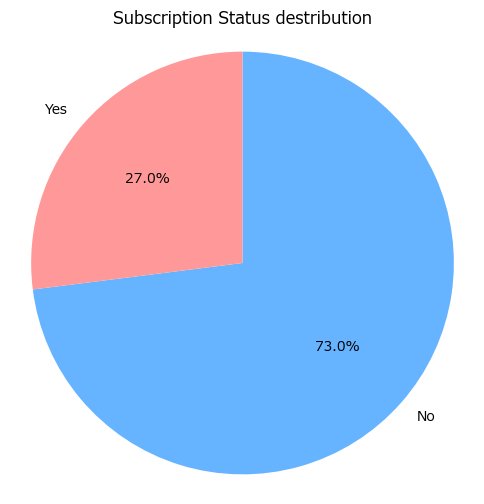

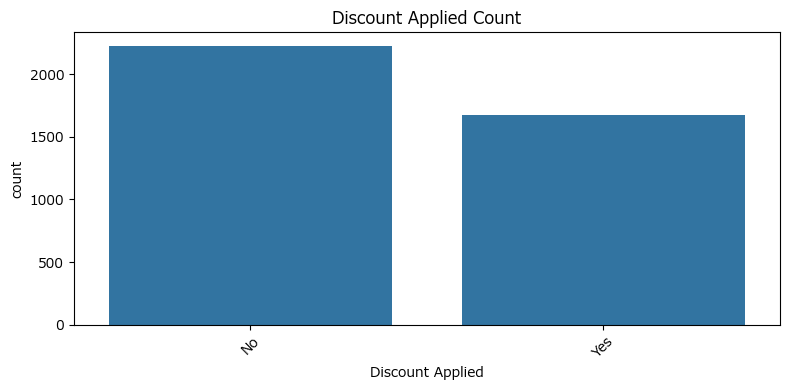

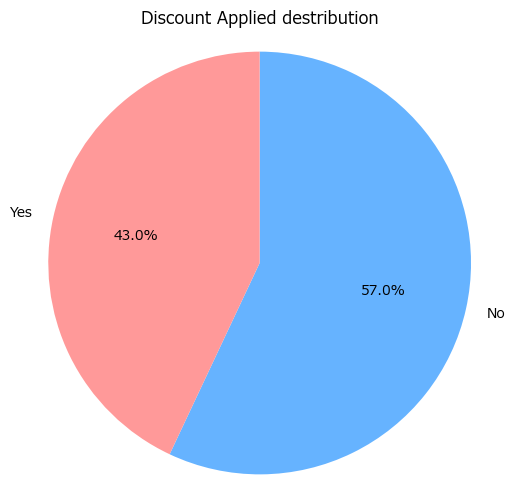

In [115]:
for column in ["Gender", "Category", "Size", "Season", "Subscription Status", "Discount Applied"]:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column, order=df[column].value_counts().index)
    plt.title(f"{column} Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    create_pie(df, column, f"{column} destribution")

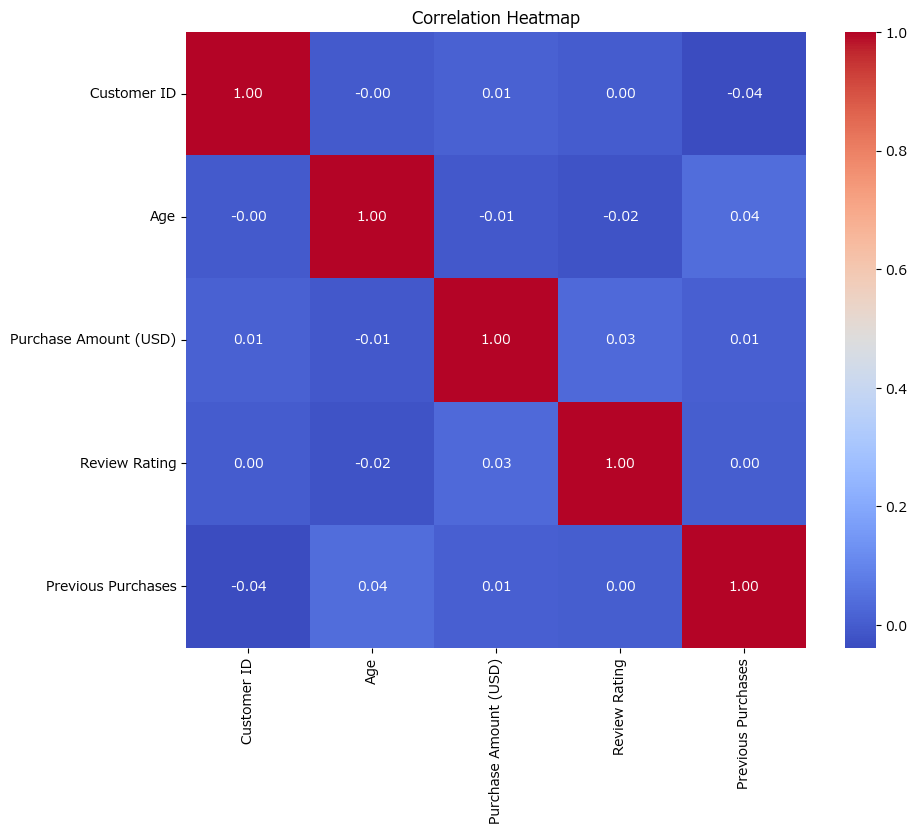

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

# とりあえず数値型だけ抜き出して相関係数を計算
corr = df.select_dtypes(include=['number']).corr()

# ヒートマップを描画
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


In [117]:
# 数値型カラムを確認
print(df.select_dtypes(include=['number']).columns)


Index(['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating',
       'Previous Purchases'],
      dtype='object')


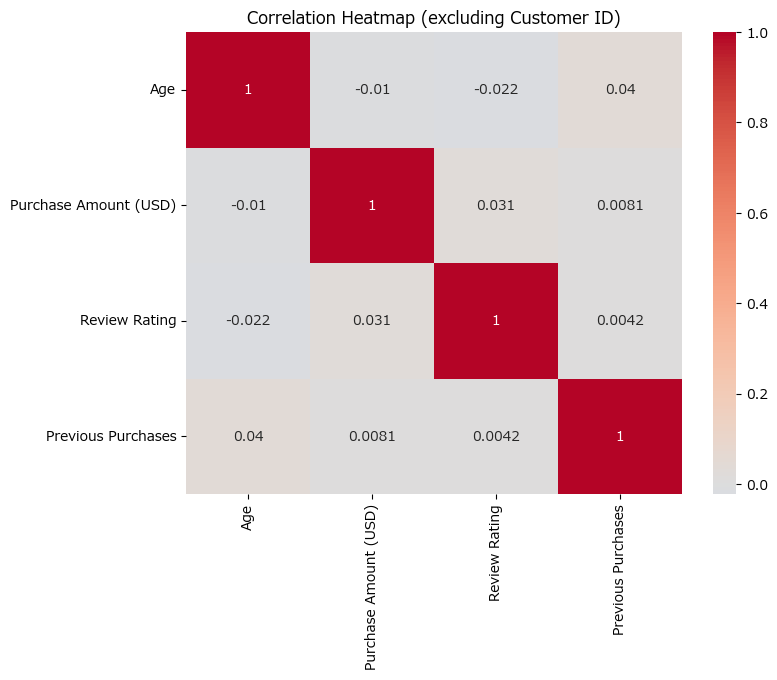

In [118]:
# Customer IDを除く
cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

# 相関行列を作成
corr = df[cols].corr()

# ヒートマップ作成
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (excluding Customer ID)')
plt.show()


In [119]:
def encode_columns_by_one_hot(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """指定した複数カラムをワンホットエンコードする。

    Args:
        df (pd.DataFrame): 元のデータフレーム
        columns (list[str]): エンコードしたいカラム名のリスト

    Returns:
        pd.DataFrame: エンコード後のデータフレーム

    Raises:
        KeyError: 指定されたカラムが存在しない場合

    Example:
        df_encoded = encode_columns(df, ["Gender", "Category"])
    """
    missing_cols = [col for col in columns if col not in df.columns]
    if missing_cols:
        raise KeyError(f"存在しないカラムが指定されました: {missing_cols}")

    df_encoded = pd.get_dummies(df, columns=columns, prefix=columns, drop_first=False)
    return df_encoded



In [120]:
# まず不要なカラムをドロップ
df = df.drop(columns=["Promo Code Used"])

# 必要なカラムを一括エンコード
columns_to_encode = [
    "Gender", "Category", "Size", "Season",
    "Subscription Status", "Shipping Type",
    "Discount Applied", "Payment Method"
]
df_encoded = encode_columns_by_one_hot(df, columns_to_encode)

In [121]:
df_encoded.head()

,Customer ID,Age,Item Purchased,Purchase Amount (USD),Location,Color,Review Rating,Previous Purchases,Frequency of Purchases,Gender_Female,...,Shipping Type_Standard,Shipping Type_Store Pickup,Discount Applied_No,Discount Applied_Yes,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo
0,1,55,Blouse,53,Kentucky,Gray,3.1,14,Fortnightly,False,...,False,False,False,True,False,False,False,False,False,True
1,2,19,Sweater,64,Maine,Maroon,3.1,2,Fortnightly,False,...,False,False,False,True,False,True,False,False,False,False
2,3,50,Jeans,73,Massachusetts,Maroon,3.1,23,Weekly,False,...,False,False,False,True,False,False,True,False,False,False
3,4,21,Sandals,90,Rhode Island,Maroon,3.5,49,Weekly,False,...,False,False,False,True,False,False,False,False,True,False
4,5,45,Blouse,49,Oregon,Turquoise,2.7,31,Annually,False,...,False,False,False,True,False,False,False,False,True,False


In [122]:
print(df_encoded.select_dtypes(include=['number', "bool"]).columns[1:])


Index(['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases',
       'Gender_Female', 'Gender_Male', 'Category_Accessories',
       'Category_Clothing', 'Category_Footwear', 'Category_Outerwear',
       'Size_L', 'Size_M', 'Size_S', 'Size_XL', 'Season_Fall', 'Season_Spring',
       'Season_Summer', 'Season_Winter', 'Subscription Status_No',
       'Subscription Status_Yes', 'Shipping Type_2-Day Shipping',
       'Shipping Type_Express', 'Shipping Type_Free Shipping',
       'Shipping Type_Next Day Air', 'Shipping Type_Standard',
       'Shipping Type_Store Pickup', 'Discount Applied_No',
       'Discount Applied_Yes', 'Payment Method_Bank Transfer',
       'Payment Method_Cash', 'Payment Method_Credit Card',
       'Payment Method_Debit Card', 'Payment Method_PayPal',
       'Payment Method_Venmo'],
      dtype='object')


In [123]:
# ピアソン相関
corr_matrix = df[['Age', 'Purchase Amount (USD)']].corr(method='pearson')
print(corr_matrix)

# スピアマン相関（順位相関の場合）
corr_matrix_spearman = df[['Age', 'Purchase Amount (USD)']].corr(method='spearman')
print(corr_matrix_spearman)


                            Age  Purchase Amount (USD)
Age                    1.000000              -0.010424
Purchase Amount (USD) -0.010424               1.000000
                            Age  Purchase Amount (USD)
Age                    1.000000              -0.010445
Purchase Amount (USD) -0.010445               1.000000


In [124]:
df["Item Purchased"].unique()

array(['Blouse', 'Sweater', 'Jeans', 'Sandals', 'Sneakers', 'Shirt',
       'Shorts', 'Coat', 'Handbag', 'Shoes', 'Dress', 'Skirt',
       'Sunglasses', 'Pants', 'Jacket', 'Hoodie', 'Jewelry', 'T-shirt',
       'Scarf', 'Hat', 'Socks', 'Backpack', 'Belt', 'Boots', 'Gloves'],
      dtype=object)

In [125]:
df["Category"].unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

In [126]:
df["Previous Purchases"].unique()

array([14,  2, 23, 49, 31, 19,  8,  4, 26, 10, 37, 34, 44, 36, 17, 46, 50,
       22, 32, 40, 16, 13,  7, 41, 45, 38, 48, 18, 15, 25, 39, 35, 29, 21,
       43,  3,  5, 24, 42, 47, 28, 20, 33,  1,  9, 12, 27, 11, 30,  6])

In [127]:
def encode_columns(df: pd.DataFrame, encoding_config: Dict[str, Dict[str, int]]) -> pd.DataFrame:
    """指定されたエンコーディング設定に基づき、DataFrameの列を数値エンコードする。

    Args:
        df (pd.DataFrame): エンコード対象のデータフレーム。
        encoding_config (Dict[str, Dict[str, int]]): カラム名と、そのカラムに適用するエンコードマッピング。

    Returns:
        pd.DataFrame: エンコード後のデータフレーム。

    Raises:
        KeyError: 指定されたカラムがDataFrameに存在しない場合。
        ValueError: エンコード後にNaNが発生した場合（未対応の値が存在する場合）。

    Example:
        df = encode_columns(df, encoding_config)
    """
    df_encoded = df.copy()
    
    for column, mapping in encoding_config.items():
        if column not in df_encoded.columns:
            raise KeyError(f"指定されたカラム {column} がDataFrameに存在しません。")

        logger.info(f"カラム {column} をエンコード中。マッピング: {mapping}")
        df_encoded[column] = df_encoded[column].map(mapping)

        if df_encoded[column].isnull().any():
            raise ValueError(f"カラム {column} にエンコードできなかった値が存在します。")

    return df_encoded

df = encode_columns(df, encoding_config)

In [128]:
df["Gender"].unique()

array([0, 1])

In [129]:
df["Size"].unique()

array([2, 0, 1, 3])

In [130]:
def categorize_age_numeric(age: int) -> int:
    """年齢を10歳ごとのグループに数値で分類する

    Args:
        age (int): 年齢

    Returns:
        int: 年齢グループを表す数値（0:10代, 1:20代, ...）

    Raises:
        None

    Example:
        >>> categorize_age_numeric(25)
        1
    """
    if pd.isna(age):
        return -1  # 欠損値は -1（または別途管理）
    if age < 20:
        return 0
    elif age < 30:
        return 1
    elif age < 40:
        return 2
    elif age < 50:
        return 3
    elif age < 60:
        return 4
    else:
        return 5

df['Age Group'] = df['Age'].apply(categorize_age_numeric)


In [131]:
df["Age Group"].value_counts()

Age Group
5    788
4    771
3    739
1    728
2    724
0    150
Name: count, dtype: int64

In [132]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases,Age Group
0,1,55,0,Blouse,0,53,Kentucky,2,Gray,3,3.1,1,Express,1,14,Venmo,Fortnightly,4
1,2,19,0,Sweater,0,64,Maine,2,Maroon,3,3.1,1,Express,1,2,Cash,Fortnightly,0
2,3,50,0,Jeans,0,73,Massachusetts,0,Maroon,0,3.1,1,Free Shipping,1,23,Credit Card,Weekly,4
3,4,21,0,Sandals,1,90,Rhode Island,1,Maroon,0,3.5,1,Next Day Air,1,49,PayPal,Weekly,1
4,5,45,0,Blouse,0,49,Oregon,1,Turquoise,0,2.7,1,Free Shipping,1,31,PayPal,Annually,3


In [133]:
df["Location"].unique()

array(['Kentucky', 'Maine', 'Massachusetts', 'Rhode Island', 'Oregon',
       'Wyoming', 'Montana', 'Louisiana', 'West Virginia', 'Missouri',
       'Arkansas', 'Hawaii', 'Delaware', 'New Hampshire', 'New York',
       'Alabama', 'Mississippi', 'North Carolina', 'California',
       'Oklahoma', 'Florida', 'Texas', 'Nevada', 'Kansas', 'Colorado',
       'North Dakota', 'Illinois', 'Indiana', 'Arizona', 'Alaska',
       'Tennessee', 'Ohio', 'New Jersey', 'Maryland', 'Vermont',
       'New Mexico', 'South Carolina', 'Idaho', 'Pennsylvania',
       'Connecticut', 'Utah', 'Virginia', 'Georgia', 'Nebraska', 'Iowa',
       'South Dakota', 'Minnesota', 'Washington', 'Wisconsin', 'Michigan'],
      dtype=object)

In [134]:
def encode_location(df: pd.DataFrame, region_mapping: dict) -> pd.DataFrame:
    def map_region(location: str) -> str:
        for region, states in region_mapping.items():
            if location in states:
                return region
        return 'Unknown'  # 万が一のため、該当しない州には 'Unknown' を設定
    
    df['Region'] = df['Location'].apply(map_region)
    return df


In [135]:
region_mapping = {
    'Northeast': ['Maine', 'New Hampshire', 'Vermont', 'Massachusetts', 'Rhode Island', 'Connecticut', 'New York', 'New Jersey', 'Pennsylvania'],
    'Midwest': ['Ohio', 'Indiana', 'Illinois', 'Michigan', 'Wisconsin', 'Missouri', 'Minnesota', 'Iowa', 'Nebraska', 'Kansas', 'North Dakota', 'South Dakota'],
    'South': ['Delaware', 'Maryland', 'Virginia', 'North Carolina', 'South Carolina', 'Georgia', 'Florida', 'Alabama', 'Mississippi', 'Tennessee', 'Kentucky', 'Arkansas', 'Louisiana', 'Oklahoma', 'Texas', 'West Virginia'],
    'West': ['Montana', 'Wyoming', 'Colorado', 'Idaho', 'Nevada', 'Utah', 'Arizona', 'Washington', 'Oregon', 'California', 'Alaska', 'Hawaii', 'New Mexico']
}

df = encode_location(df, region_mapping)

In [136]:
df["Color"].unique()

array(['Gray', 'Maroon', 'Turquoise', 'White', 'Charcoal', 'Silver',
       'Pink', 'Purple', 'Olive', 'Gold', 'Violet', 'Teal', 'Lavender',
       'Black', 'Green', 'Peach', 'Red', 'Cyan', 'Brown', 'Beige',
       'Orange', 'Indigo', 'Yellow', 'Magenta', 'Blue'], dtype=object)

In [137]:
# 1. カラーごとの売上合計を計算
color_sales = df.groupby('Color')['Purchase Amount (USD)'].sum().reset_index()

# 2. カラーごとの売上平均を計算
color_avg_sales = df.groupby('Color')['Purchase Amount (USD)'].mean().reset_index()

# 3. 売上合計や平均を色ごとに並べて確認
color_sales = color_sales.sort_values('Purchase Amount (USD)', ascending=False)
color_avg_sales = color_avg_sales.sort_values('Purchase Amount (USD)', ascending=False)

# 結果を表示
print(color_sales)


        Color  Purchase Amount (USD)
8       Green                  11104
20       Teal                  10459
24     Yellow                  10308
13      Olive                  10292
5        Cyan                  10274
22     Violet                  10245
7        Gray                   9936
19     Silver                   9832
1       Black                   9753
12     Maroon                   9405
14     Orange                   9377
4    Charcoal                   9277
16       Pink                   9270
17     Purple                   9062
23      White                   8895
0       Beige                   8881
15      Peach                   8819
18        Red                   8779
10   Lavender                   8692
11    Magenta                   8684
2        Blue                   8657
6        Gold                   8419
3       Brown                   8328
9      Indigo                   8269
21  Turquoise                   8064


([<matplotlib.axis.XTick at 0x14e4860e490>,
 [Text(0, 0, '10代'),
  Text(1, 0, '20代'),
  Text(2, 0, '30代'),
  Text(3, 0, '40代'),
  Text(4, 0, '50代'),
  Text(5, 0, 'シニア')])

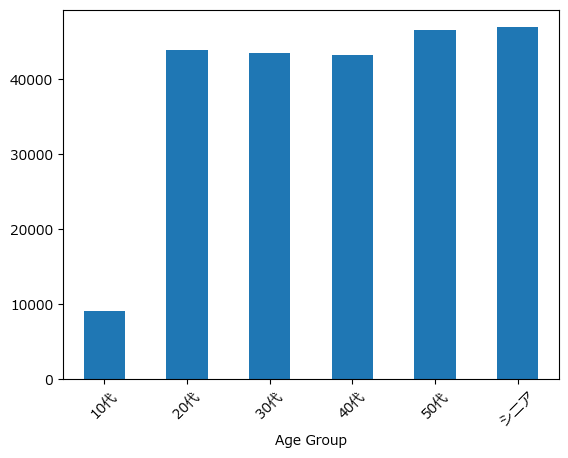

In [138]:
age_group_df = df.groupby("Age Group")["Purchase Amount (USD)"].sum()
age_group = ["10代", "20代", "30代", "40代", "50代", "シニア"]

age_group_df.plot(kind="bar")
plt.xticks(ticks=range(len(age_group)), labels=age_group, rotation=45)



([<matplotlib.axis.XTick at 0x14e48abb9d0>,
 [Text(0, 0, '10代'),
  Text(1, 0, '20代'),
  Text(2, 0, '30代'),
  Text(3, 0, '40代'),
  Text(4, 0, '50代'),
  Text(5, 0, 'シニア')])

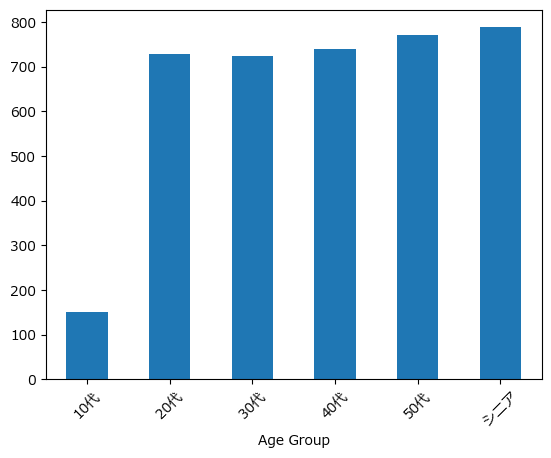

In [139]:
df["Age Group"].value_counts().sort_index().plot(kind="bar")
plt.xticks(ticks=range(len(age_group)), labels=age_group, rotation=45)

In [140]:
def group_graph():
    group_df = df.groupby("Gender")["Purchase Amount (USD)"].sum()
    group_labels = ["男性", "女性"]

    group_df.plot(kind="bar")
    plt.title(f"Gender 別売上(USD)")
    plt.xticks(ticks=range(len(group_labels)), labels=group_labels, rotation=45)
    plt.show()


    df["Gender"].value_counts().sort_index().plot(kind="bar")
    plt.xticks(ticks=range(len(group_labels)), labels=group_labels, rotation=45)
    plt.title(f"Gender 別総数")
    plt.show()